<a href="https://colab.research.google.com/github/shahwaiz-9/Machine_Learning/blob/main/KNN_in_depth_(_hyper_parameters_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Dependencies**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score

In [32]:
import kagglehub

path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iris' dataset.
Path to dataset files: /kaggle/input/iris


In [33]:
df = pd.read_csv(f'{path}/Iris.csv')
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


##**Overview**

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [35]:
counts = df['Species'].value_counts()

<Axes: xlabel='Species'>

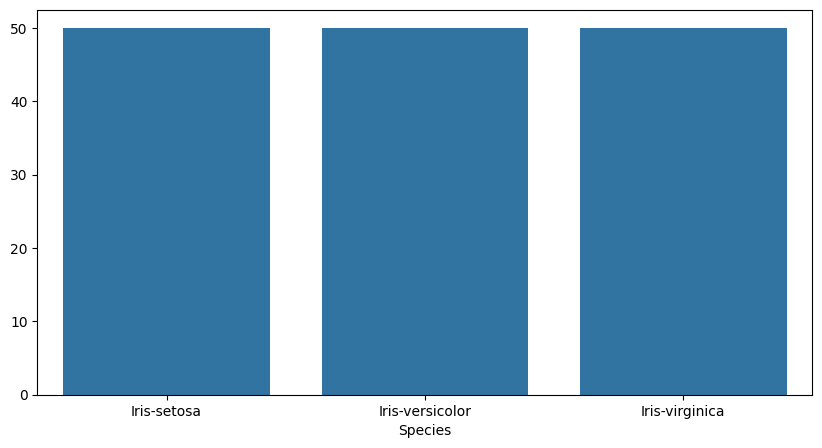

In [47]:
plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values)

###**Encoding**

In [36]:
X = df.drop(columns = {'Id', 'Species'})
y = df['Species']

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)


In [38]:

le = LabelEncoder()
y_encoded = le.fit_transform(df['Species'])

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Type of y_train: {type(y_train)}")
print(f"First 5 elements of y_train: {y_train[:5]}")
print(f"Type of y_test: {type(y_test)}")
print(f"First 5 elements of y_test: {y_test[:5]}")

Type of y_train: <class 'numpy.ndarray'>
First 5 elements of y_train: [1 2 2 1 2]
Type of y_test: <class 'numpy.ndarray'>
First 5 elements of y_test: [1 0 2 1 1]


#**Euclidean Distance**

##We will train 3 models
1. Without any scaling
2. With min-max
3. With Standard-Scalar

In [29]:
X_train_1  = X_train.copy()
X_test_1 = X_test.copy()

simple_model = KNeighborsClassifier()
simple_model.fit(X_train_1, y_train)
y_pred = simple_model.predict(X_test_1)
simple_accuracy = accuracy_score(y_test, y_pred)
print(simple_accuracy)


1.0


In [41]:
X_train_2 = X_train.copy()
X_test_2 = X_test.copy()

scaler = MinMaxScaler()

X_train_2 = scaler.fit_transform(X_train_2)
X_test_2 = scaler.transform(X_test_2)

min_max_model = KNeighborsClassifier()
min_max_model.fit(X_train_2, y_train)

y_pred = min_max_model.predict(X_test_2)
min_max_accuracy = accuracy_score(y_test, y_pred)
print(min_max_accuracy)


1.0


In [42]:
X_train_3 = X_train.copy()
X_test_3 = X_test.copy()

X_train_3 = StandardScaler().fit_transform(X_train_3)
X_test_3 = StandardScaler().fit_transform(X_test_3)

standard_model = KNeighborsClassifier()
standard_model.fit(X_train_3, y_train)

y_pred = standard_model.predict(X_test_3)
standard_accuracy = accuracy_score(y_test, y_pred)
print(standard_accuracy)

0.9333333333333333


<BarContainer object of 3 artists>

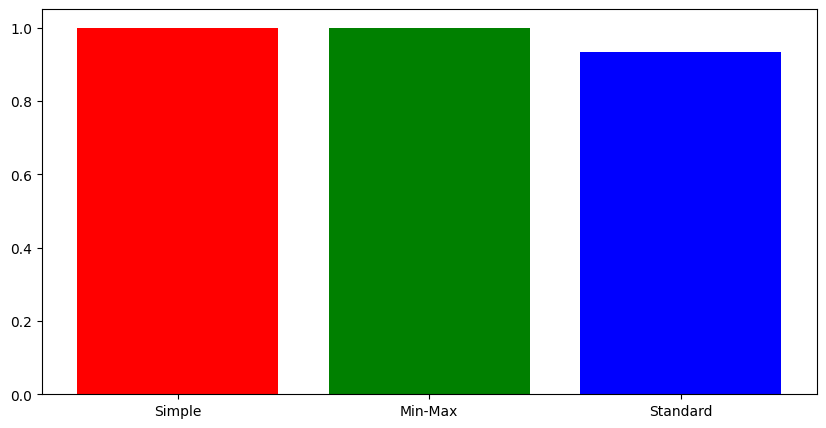

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(
    ['Simple', 'Min-Max', 'Standard'],
    [simple_accuracy, min_max_accuracy, standard_accuracy],
    color=['red', 'green', 'blue']
)

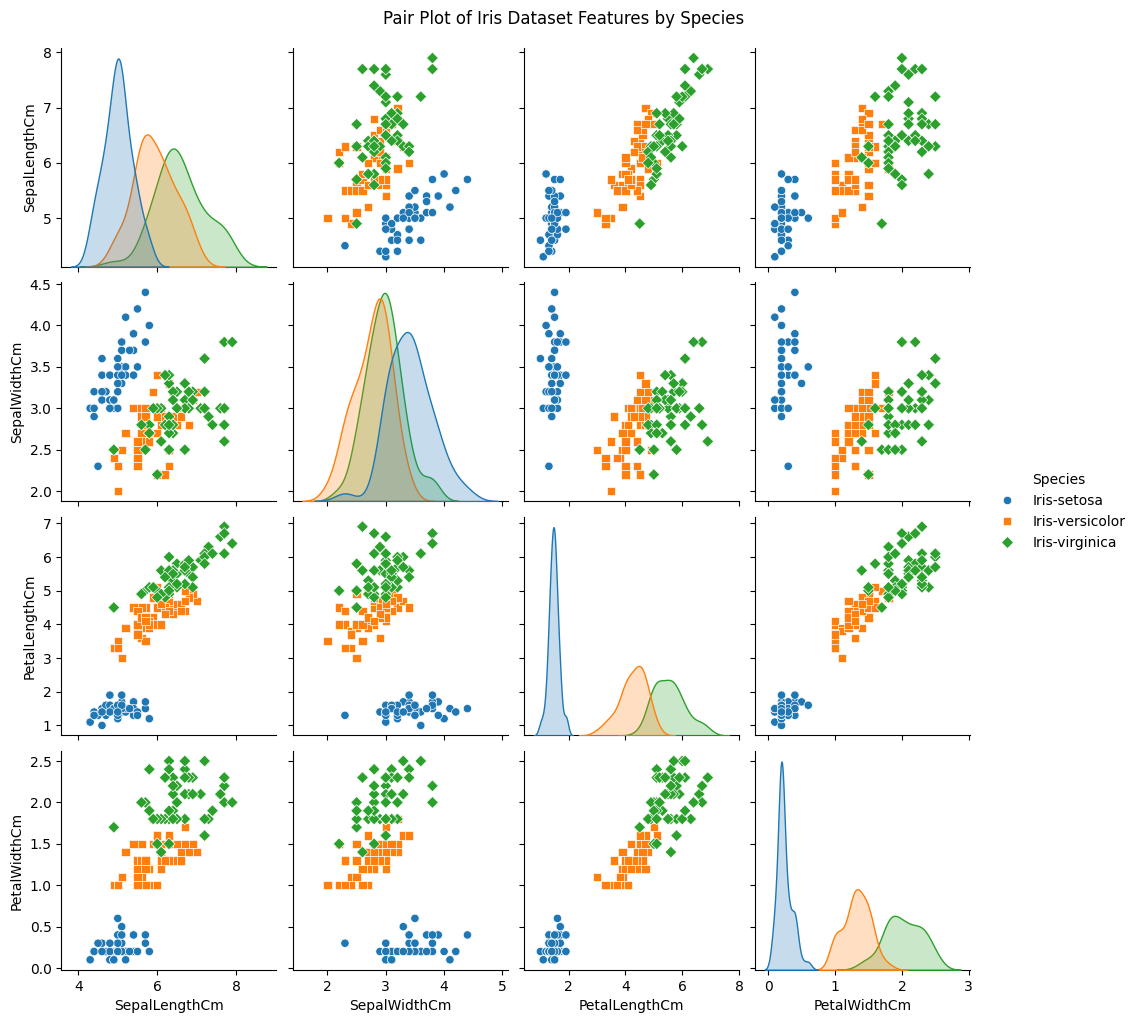

In [40]:
sns.pairplot(df.drop('Id', axis=1), hue='Species', markers=['o', 's', 'D'])
plt.suptitle('Pair Plot of Iris Dataset Features by Species', y=1.02)
plt.show()

Simple KNN gives 100% accuracy!
 By looking at the graphs the classes are clearly very seprable there is a clear difference in the ranges of each class hence it is Quite easy to predict for KNN.

##**Finding Optimal Value of k.**

Since Simple and Min - Max model gives 100% accuracy we will not touch these models. We will find for Standard Scaler model.
note: *By default value of k is 5.*

In [55]:
k_values = [3 , 5 , 7, 9 , 11, 13, 15]
accuracy_dict = dict()
for k_val in k_values:

  model = KNeighborsClassifier(n_neighbors=k_val)
  model.fit(X_train_3, y_train)
  y_pred = model.predict(X_test_3)
  accuracy = accuracy_score(y_test, y_pred)
  accuracy_dict[k_val] = accuracy

display(accuracy_dict)

{3: 0.9111111111111111,
 5: 0.9333333333333333,
 7: 0.9555555555555556,
 9: 0.9555555555555556,
 11: 0.9777777777777777,
 13: 0.9555555555555556,
 15: 0.9111111111111111}

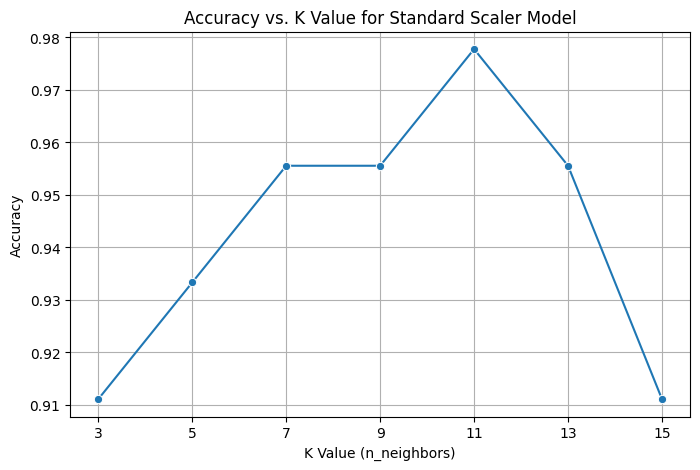

In [57]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), marker='o')
plt.title('Accuracy vs. K Value for Standard Scaler Model')
plt.xlabel('K Value (n_neighbors)')
plt.ylabel('Accuracy')
plt.xticks(list(accuracy_dict.keys()))
plt.grid(True)
plt.show()

Sicne there was a constant growing line when we plot with 3, 5, 7 therefore I go ahead and added more neighbours range turns out the model gives maximum accuracy at K = 11

## Model Evaluation

In [70]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import numpy as np

def evaluate_model(model, X_test_data, y_true, model_name, le_encoder=None):
    y_pred = model.predict(X_test_data)


    y_true = np.asarray(y_true, dtype=int)


    if y_pred.dtype == 'object' and le_encoder is not None:
        y_pred = le_encoder.transform(y_pred)
    else:
        y_pred = np.asarray(y_pred, dtype=int)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (macro avg): {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall (macro avg): {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1 Score (macro avg): {f1_score(y_true, y_pred, average='macro'):.4f}")

    try:
        y_proba = model.predict_proba(X_test_data)
        roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        print(f"ROC AUC (macro, ovr): {roc_auc:.4f}")
    except AttributeError:
        print("Model does not have predict_proba for ROC AUC.")
    except ValueError as e:
        print(f"Could not calculate ROC AUC: {e}")

    print("\nClassification Report:")

    target_names = le_encoder.classes_ if le_encoder is not None else [str(i) for i in np.unique(y_true)]
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    heatmap_labels = le_encoder.classes_ if le_encoder is not None else [str(i) for i in np.unique(y_true)]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=heatmap_labels,
                yticklabels=heatmap_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Evaluating Simple KNN Model


--- Simple KNN Evaluation ---
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1 Score (macro avg): 1.0000
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



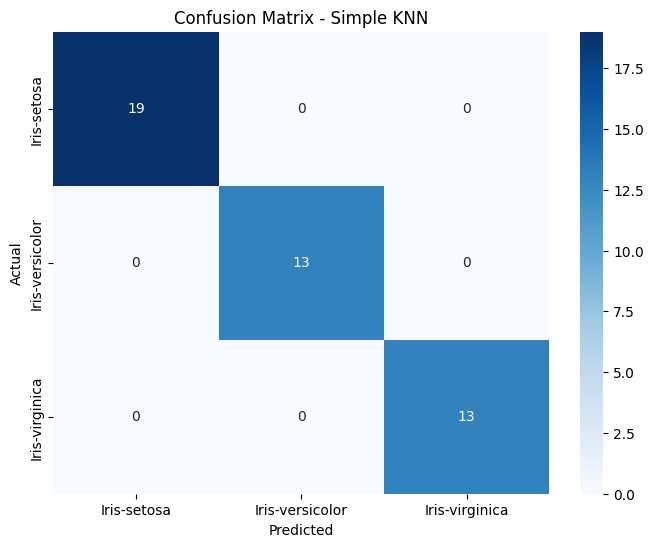

In [71]:
evaluate_model(simple_model, X_test_1, y_test, 'Simple KNN', le)

### Evaluating Min-Max Scaled KNN Model


--- Min-Max Scaled KNN Evaluation ---
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1 Score (macro avg): 1.0000
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



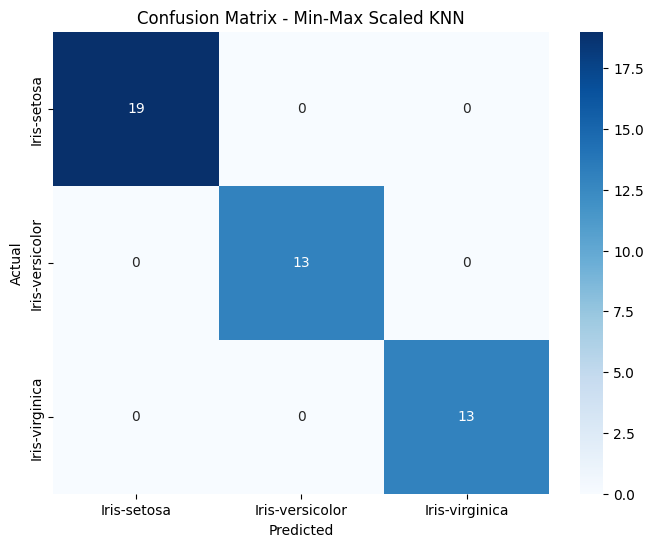

In [72]:
evaluate_model(min_max_model, X_test_2, y_test, 'Min-Max Scaled KNN', le)

### Evaluating Standard Scaled KNN Model (Optimal k=11)


--- Standard Scaled KNN (k=11) Evaluation ---
Accuracy: 0.9778
Precision (macro avg): 0.9762
Recall (macro avg): 0.9744
F1 Score (macro avg): 0.9743
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



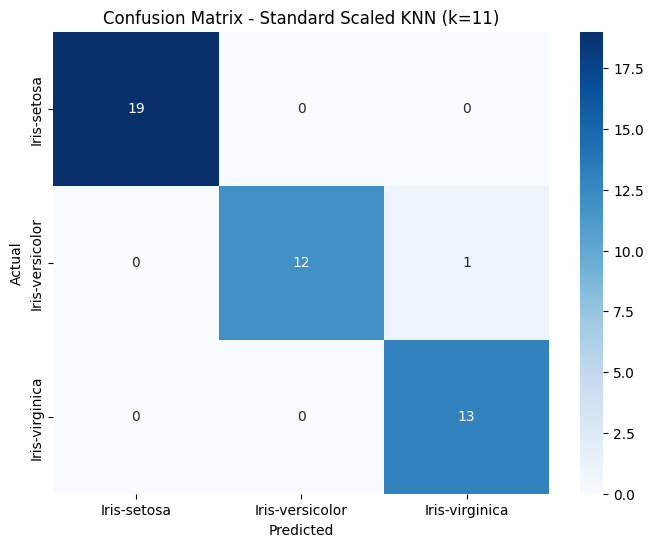

In [85]:

optimal_standard_model = KNeighborsClassifier(n_neighbors=11)
optimal_standard_model.fit(X_train_3, y_train)
optimal_pred = optimal_standard_model.predict(X_test_3)
optimal_accuracy = accuracy_score(y_test, optimal_pred)
evaluate_model(optimal_standard_model, X_test_3, y_test, 'Standard Scaled KNN (k=11)', le)

##**Manhattan Distance - Model Training**

### 1. Without any scaling (Manhattan Distance)

In [73]:
X_train_manh_1  = X_train.copy()
X_test_manh_1 = X_test.copy()

simple_manh_model = KNeighborsClassifier(metric='manhattan')
simple_manh_model.fit(X_train_manh_1, y_train)
y_pred_manh = simple_manh_model.predict(X_test_manh_1)
simple_manh_accuracy = accuracy_score(y_test, y_pred_manh)
print(f"Simple KNN (Manhattan) Accuracy: {simple_manh_accuracy}")

Simple KNN (Manhattan) Accuracy: 1.0


### 2. With Min-Max Scaling (Manhattan Distance)

In [74]:
X_train_manh_2 = X_train.copy()
X_test_manh_2 = X_test.copy()

scaler_manh = MinMaxScaler()

X_train_manh_2 = scaler_manh.fit_transform(X_train_manh_2)
X_test_manh_2 = scaler_manh.transform(X_test_manh_2)

min_max_manh_model = KNeighborsClassifier(metric='manhattan')
min_max_manh_model.fit(X_train_manh_2, y_train)

y_pred_manh = min_max_manh_model.predict(X_test_manh_2)
min_max_manh_accuracy = accuracy_score(y_test, y_pred_manh)
print(f"Min-Max Scaled KNN (Manhattan) Accuracy: {min_max_manh_accuracy}")

Min-Max Scaled KNN (Manhattan) Accuracy: 1.0


### 3. With Standard Scaling (Manhattan Distance)

In [75]:
X_train_manh_3 = X_train.copy()
X_test_manh_3 = X_test.copy()

X_train_manh_3 = StandardScaler().fit_transform(X_train_manh_3)
X_test_manh_3 = StandardScaler().fit_transform(X_test_manh_3)

standard_manh_model = KNeighborsClassifier(metric='manhattan')
standard_manh_model.fit(X_train_manh_3, y_train)

y_pred_manh = standard_manh_model.predict(X_test_manh_3)
standard_manh_accuracy = accuracy_score(y_test, y_pred_manh)
print(f"Standard Scaled KNN (Manhattan) Accuracy: {standard_manh_accuracy}")

Standard Scaled KNN (Manhattan) Accuracy: 0.9555555555555556


### Comparison of Manhattan Distance Models

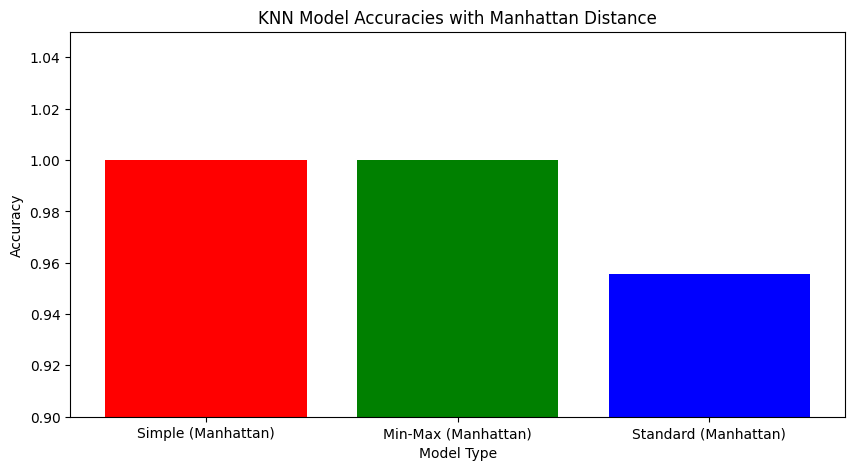

In [76]:
plt.figure(figsize=(10, 5))
plt.bar(
    ['Simple (Manhattan)', 'Min-Max (Manhattan)', 'Standard (Manhattan)'],
    [simple_manh_accuracy, min_max_manh_accuracy, standard_manh_accuracy],
    color=['red', 'green', 'blue']
)
plt.title('KNN Model Accuracies with Manhattan Distance')
plt.xlabel('Model Type')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.05)
plt.show()

##**Finding Optimal Value of k (Manhattan Distance)**

Since Min-Max model gives 100% accuracy, we will focus on finding the optimal 'k' for the Standard Scaler model using Manhattan distance.

In [77]:
k_values_manh = [3 , 5 , 7, 9 , 11, 13, 15]
accuracy_dict_manh = dict()
for k_val in k_values_manh:
  model_manh = KNeighborsClassifier(n_neighbors=k_val, metric='manhattan')
  model_manh.fit(X_train_manh_3, y_train)
  y_pred_manh = model_manh.predict(X_test_manh_3)
  accuracy_manh = accuracy_score(y_test, y_pred_manh)
  accuracy_dict_manh[k_val] = accuracy_manh

display(accuracy_dict_manh)

{3: 0.9333333333333333,
 5: 0.9555555555555556,
 7: 0.9555555555555556,
 9: 0.9333333333333333,
 11: 0.9111111111111111,
 13: 0.9333333333333333,
 15: 0.9111111111111111}

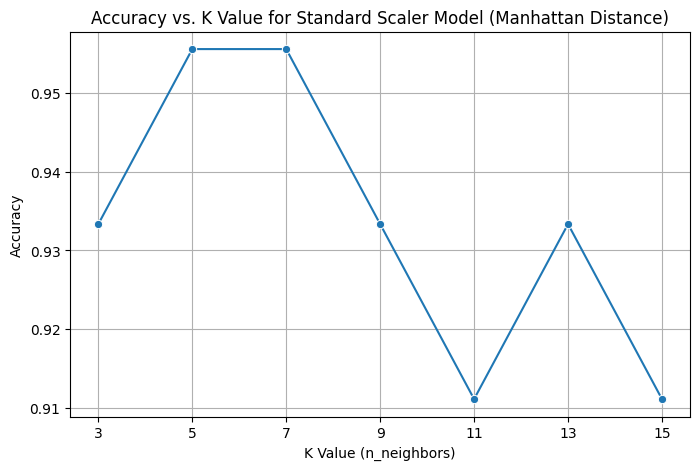

In [78]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(accuracy_dict_manh.keys()), y=list(accuracy_dict_manh.values()), marker='o')
plt.title('Accuracy vs. K Value for Standard Scaler Model (Manhattan Distance)')
plt.xlabel('K Value (n_neighbors)')
plt.ylabel('Accuracy')
plt.xticks(list(accuracy_dict_manh.keys()))
plt.grid(True)
plt.show()

The grapgh

##**Model Evaluation (Manhattan Distance)**

### Evaluating Simple KNN Model (Manhattan Distance)


--- Simple KNN (Manhattan) Evaluation ---
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1 Score (macro avg): 1.0000
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



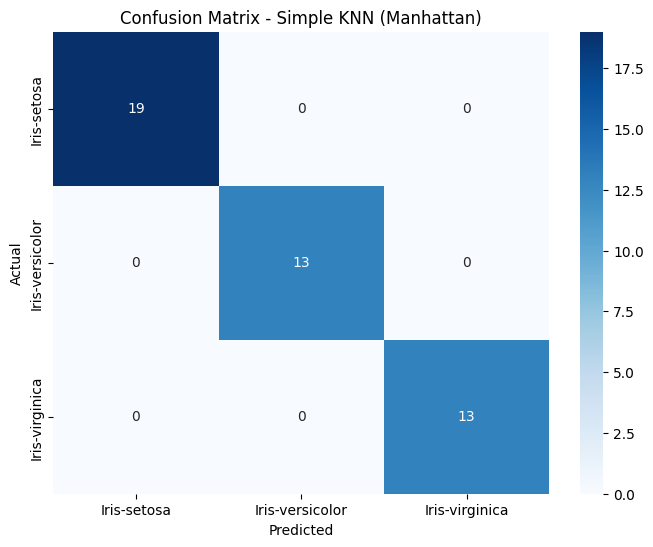

In [79]:
evaluate_model(simple_manh_model, X_test_manh_1, y_test, 'Simple KNN (Manhattan)', le)

### Evaluating Min-Max Scaled KNN Model (Manhattan Distance)


--- Min-Max Scaled KNN (Manhattan) Evaluation ---
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1 Score (macro avg): 1.0000
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



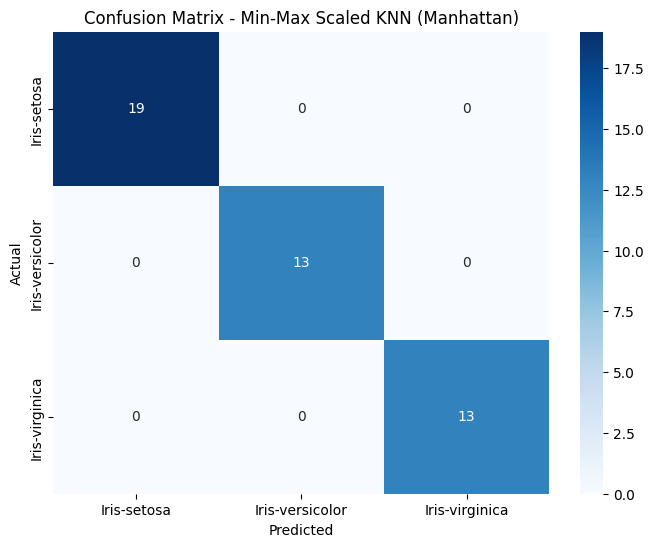

In [80]:
evaluate_model(min_max_manh_model, X_test_manh_2, y_test, 'Min-Max Scaled KNN (Manhattan)', le)

### Evaluating Standard Scaled KNN Model (Optimal k for Manhattan Distance)


--- Standard Scaled KNN (Manhattan, k=5) Evaluation ---
Accuracy: 0.9556
Precision (macro avg): 0.9556
Recall (macro avg): 0.9487
F1 Score (macro avg): 0.9484
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.87      1.00      0.93        13

       accuracy                           0.96        45
      macro avg       0.96      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



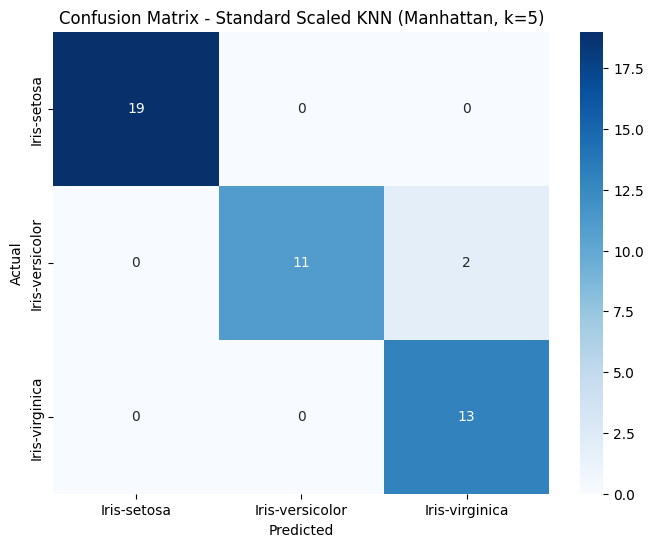

In [81]:
# Determine the optimal k from the tuning results for Manhattan distance
optimal_k_manh = max(accuracy_dict_manh, key=accuracy_dict_manh.get)

optimal_standard_manh_model = KNeighborsClassifier(n_neighbors=optimal_k_manh, metric='manhattan')
optimal_standard_manh_model.fit(X_train_manh_3, y_train)

evaluate_model(optimal_standard_manh_model, X_test_manh_3, y_test, f'Standard Scaled KNN (Manhattan, k={optimal_k_manh})', le)

##**Comparison**

/tmp/ipykernel_6240/2559010198.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


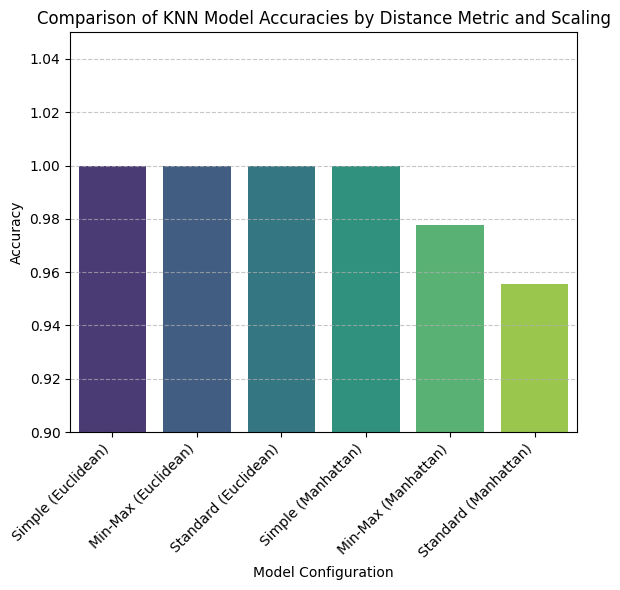

In [86]:
model_names = [
    'Simple (Euclidean)', 'Min-Max (Euclidean)', 'Standard (Euclidean)',
    'Simple (Manhattan)', 'Min-Max (Manhattan)', 'Standard (Manhattan)'
]
accuracies = [
    simple_accuracy, simple_manh_accuracy,  min_max_accuracy, min_max_manh_accuracy, optimal_accuracy,
    standard_manh_accuracy
]

plt.figure(figsize=(6, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Comparison of KNN Model Accuracies by Distance Metric and Scaling')
plt.xlabel('Model Configuration')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.05)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The Maximum accuracy in manhathan for Standard Scaler is 95% where as in Euclidean it is 97%.

## **Feature Selection (Chi-Squared Approach)**

In [87]:
from sklearn.feature_selection import SelectKBest, chi2
import time


k_best_features = SelectKBest(chi2, k=3)
X_new = k_best_features.fit_transform(X, y)


selected_feature_indices = k_best_features.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]

X_selected = pd.DataFrame(X_new, columns=selected_feature_names)

print("Original features:", X.columns.tolist())
print("Selected 3 features:", selected_feature_names.tolist())
display(X_selected.head())

# Split the selected features data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y, test_size=0.3, random_state=42)

Original features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Selected 3 features: ['SepalLengthCm', 'PetalLengthCm', 'PetalWidthCm']


,SepalLengthCm,PetalLengthCm,PetalWidthCm
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2


## **Euclidean Distance - Models with Selected Features**

### 1. Without any scaling (Euclidean Distance, 3 features)

Simple KNN (Euclidean, 3 features) Accuracy: 1.0000
Training Time: 0.0020 seconds
Prediction Time: 0.0027 seconds

--- Simple KNN (Euclidean, 3 Features) Evaluation ---
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1 Score (macro avg): 1.0000
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



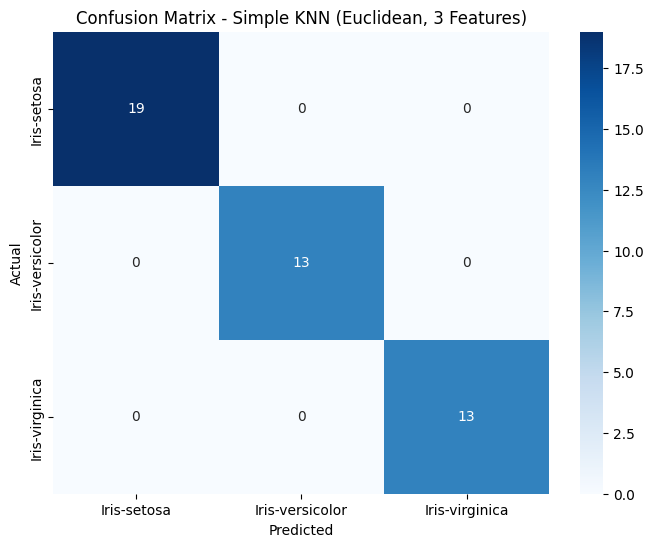

In [88]:
X_train_euc_selected_1  = X_train_selected.copy()
X_test_euc_selected_1 = X_test_selected.copy()

start_time = time.perf_counter()
simple_euc_selected_model = KNeighborsClassifier()
simple_euc_selected_model.fit(X_train_euc_selected_1, y_train_selected)
training_time_simple_euc_selected = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_simple_euc_selected = simple_euc_selected_model.predict(X_test_euc_selected_1)
prediction_time_simple_euc_selected = time.perf_counter() - start_time

simple_euc_selected_accuracy = accuracy_score(y_test_selected, y_pred_simple_euc_selected)

print(f"Simple KNN (Euclidean, 3 features) Accuracy: {simple_euc_selected_accuracy:.4f}")
print(f"Training Time: {training_time_simple_euc_selected:.4f} seconds")
print(f"Prediction Time: {prediction_time_simple_euc_selected:.4f} seconds")

evaluate_model(simple_euc_selected_model, X_test_euc_selected_1, y_test_selected, 'Simple KNN (Euclidean, 3 Features)', le)

### 2. With Min-Max Scaling (Euclidean Distance, 3 features)

Min-Max Scaled KNN (Euclidean, 3 features) Accuracy: 0.9778
Training Time: 0.0011 seconds
Prediction Time: 0.0018 seconds

--- Min-Max Scaled KNN (Euclidean, 3 Features) Evaluation ---
Accuracy: 0.9778
Precision (macro avg): 0.9762
Recall (macro avg): 0.9744
F1 Score (macro avg): 0.9743
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



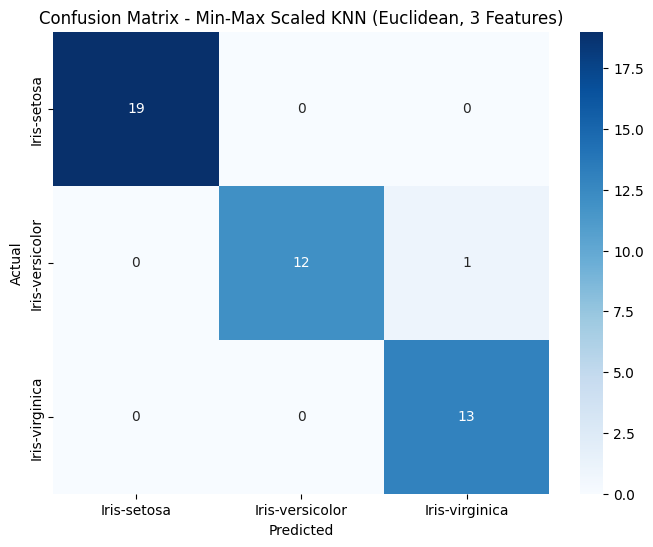

In [89]:
X_train_euc_selected_2 = X_train_selected.copy()
X_test_euc_selected_2 = X_test_selected.copy()

scaler_euc_selected = MinMaxScaler()
X_train_euc_selected_2 = scaler_euc_selected.fit_transform(X_train_euc_selected_2)
X_test_euc_selected_2 = scaler_euc_selected.transform(X_test_euc_selected_2)

start_time = time.perf_counter()
min_max_euc_selected_model = KNeighborsClassifier()
min_max_euc_selected_model.fit(X_train_euc_selected_2, y_train_selected)
training_time_min_max_euc_selected = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_min_max_euc_selected = min_max_euc_selected_model.predict(X_test_euc_selected_2)
prediction_time_min_max_euc_selected = time.perf_counter() - start_time

min_max_euc_selected_accuracy = accuracy_score(y_test_selected, y_pred_min_max_euc_selected)

print(f"Min-Max Scaled KNN (Euclidean, 3 features) Accuracy: {min_max_euc_selected_accuracy:.4f}")
print(f"Training Time: {training_time_min_max_euc_selected:.4f} seconds")
print(f"Prediction Time: {prediction_time_min_max_euc_selected:.4f} seconds")

evaluate_model(min_max_euc_selected_model, X_test_euc_selected_2, y_test_selected, 'Min-Max Scaled KNN (Euclidean, 3 Features)', le)

### 3. With Standard Scaling (Euclidean Distance, 3 features) - Optimal k

Optimal K for Standard Scaled KNN (Euclidean, 3 features): 11


{3: 0.9333333333333333,
 5: 0.9111111111111111,
 7: 0.9333333333333333,
 9: 0.9333333333333333,
 11: 0.9555555555555556,
 13: 0.9333333333333333,
 15: 0.9111111111111111}

Standard Scaled KNN (Euclidean, 3 features, k=11) Accuracy: 0.9556
Training Time: 0.0013 seconds
Prediction Time: 0.0016 seconds

--- Standard Scaled KNN (Euclidean, 3 Features, k=11) Evaluation ---
Accuracy: 0.9556
Precision (macro avg): 0.9556
Recall (macro avg): 0.9487
F1 Score (macro avg): 0.9484
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.87      1.00      0.93        13

       accuracy                           0.96        45
      macro avg       0.96      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



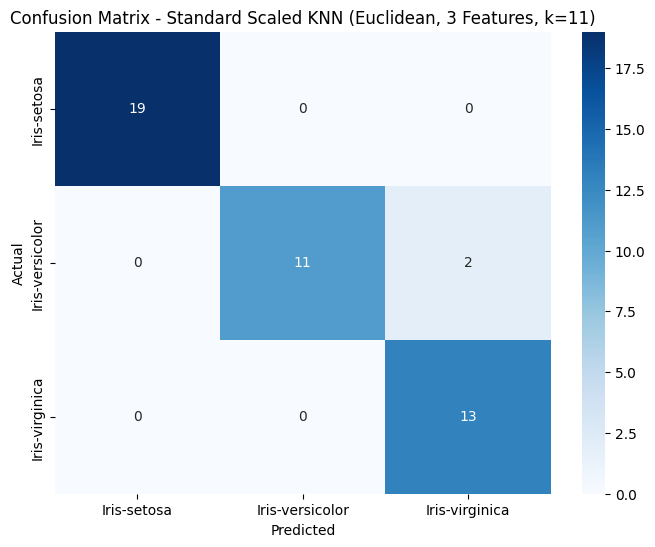

In [90]:
X_train_euc_selected_3 = X_train_selected.copy()
X_test_euc_selected_3 = X_test_selected.copy()

X_train_euc_selected_3 = StandardScaler().fit_transform(X_train_euc_selected_3)
X_test_euc_selected_3 = StandardScaler().fit_transform(X_test_euc_selected_3)

k_values_euc_selected = [3, 5, 7, 9, 11, 13, 15]
accuracy_dict_euc_selected = dict()
for k_val in k_values_euc_selected:
    model_euc_selected = KNeighborsClassifier(n_neighbors=k_val)
    model_euc_selected.fit(X_train_euc_selected_3, y_train_selected)
    y_pred_euc_selected = model_euc_selected.predict(X_test_euc_selected_3)
    accuracy_euc_selected = accuracy_score(y_test_selected, y_pred_euc_selected)
    accuracy_dict_euc_selected[k_val] = accuracy_euc_selected

optimal_k_euc_selected = max(accuracy_dict_euc_selected, key=accuracy_dict_euc_selected.get)
print(f"Optimal K for Standard Scaled KNN (Euclidean, 3 features): {optimal_k_euc_selected}")
display(accuracy_dict_euc_selected)

# Train the optimal model
start_time = time.perf_counter()
optimal_standard_euc_selected_model = KNeighborsClassifier(n_neighbors=optimal_k_euc_selected)
optimal_standard_euc_selected_model.fit(X_train_euc_selected_3, y_train_selected)
training_time_optimal_standard_euc_selected = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_optimal_standard_euc_selected = optimal_standard_euc_selected_model.predict(X_test_euc_selected_3)
prediction_time_optimal_standard_euc_selected = time.perf_counter() - start_time

optimal_standard_euc_selected_accuracy = accuracy_score(y_test_selected, y_pred_optimal_standard_euc_selected)

print(f"Standard Scaled KNN (Euclidean, 3 features, k={optimal_k_euc_selected}) Accuracy: {optimal_standard_euc_selected_accuracy:.4f}")
print(f"Training Time: {training_time_optimal_standard_euc_selected:.4f} seconds")
print(f"Prediction Time: {prediction_time_optimal_standard_euc_selected:.4f} seconds")

evaluate_model(optimal_standard_euc_selected_model, X_test_euc_selected_3, y_test_selected, f'Standard Scaled KNN (Euclidean, 3 Features, k={optimal_k_euc_selected})', le)

## **Manhattan Distance - Models with Selected Features**

### 1. Without any scaling (Manhattan Distance, 3 features)

Simple KNN (Manhattan, 3 features) Accuracy: 1.0000
Training Time: 0.0018 seconds
Prediction Time: 0.0026 seconds

--- Simple KNN (Manhattan, 3 Features) Evaluation ---
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1 Score (macro avg): 1.0000
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



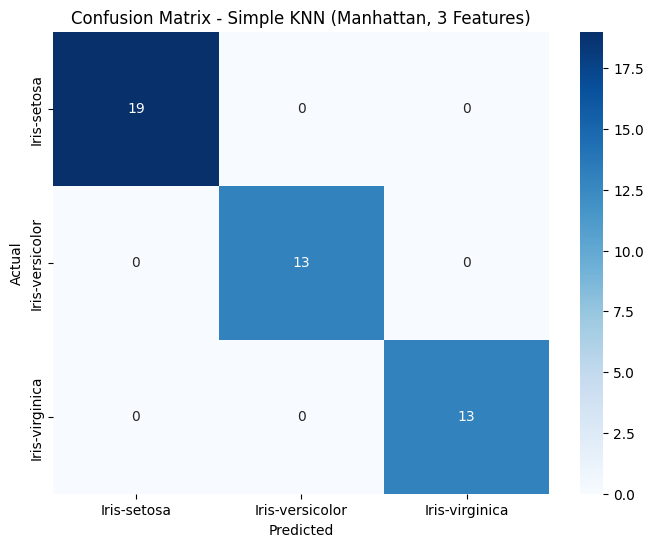

In [91]:
X_train_manh_selected_1  = X_train_selected.copy()
X_test_manh_selected_1 = X_test_selected.copy()

start_time = time.perf_counter()
simple_manh_selected_model = KNeighborsClassifier(metric='manhattan')
simple_manh_selected_model.fit(X_train_manh_selected_1, y_train_selected)
training_time_simple_manh_selected = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_simple_manh_selected = simple_manh_selected_model.predict(X_test_manh_selected_1)
prediction_time_simple_manh_selected = time.perf_counter() - start_time

simple_manh_selected_accuracy = accuracy_score(y_test_selected, y_pred_simple_manh_selected)

print(f"Simple KNN (Manhattan, 3 features) Accuracy: {simple_manh_selected_accuracy:.4f}")
print(f"Training Time: {training_time_simple_manh_selected:.4f} seconds")
print(f"Prediction Time: {prediction_time_simple_manh_selected:.4f} seconds")

evaluate_model(simple_manh_selected_model, X_test_manh_selected_1, y_test_selected, 'Simple KNN (Manhattan, 3 Features)', le)

### 2. With Min-Max Scaling (Manhattan Distance, 3 features)

Min-Max Scaled KNN (Manhattan, 3 features) Accuracy: 0.9778
Training Time: 0.0013 seconds
Prediction Time: 0.0020 seconds

--- Min-Max Scaled KNN (Manhattan, 3 Features) Evaluation ---
Accuracy: 0.9778
Precision (macro avg): 0.9762
Recall (macro avg): 0.9744
F1 Score (macro avg): 0.9743
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



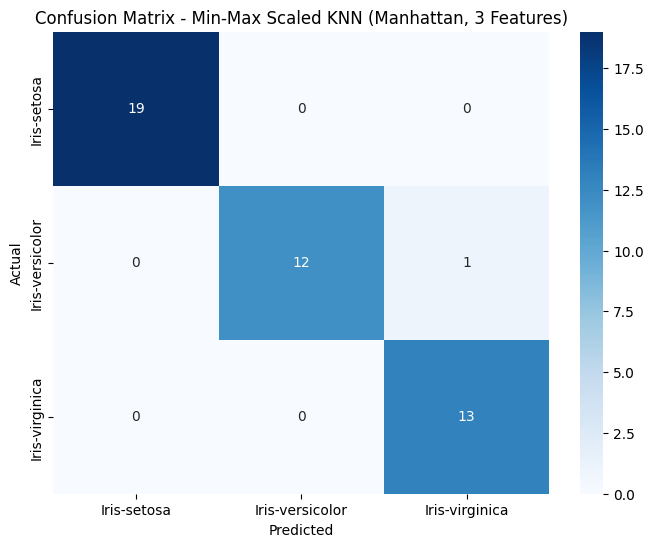

In [92]:
X_train_manh_selected_2 = X_train_selected.copy()
X_test_manh_selected_2 = X_test_selected.copy()

scaler_manh_selected = MinMaxScaler()
X_train_manh_selected_2 = scaler_manh_selected.fit_transform(X_train_manh_selected_2)
X_test_manh_selected_2 = scaler_manh_selected.transform(X_test_manh_selected_2)

start_time = time.perf_counter()
min_max_manh_selected_model = KNeighborsClassifier(metric='manhattan')
min_max_manh_selected_model.fit(X_train_manh_selected_2, y_train_selected)
training_time_min_max_manh_selected = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_min_max_manh_selected = min_max_manh_selected_model.predict(X_test_manh_selected_2)
prediction_time_min_max_manh_selected = time.perf_counter() - start_time

min_max_manh_selected_accuracy = accuracy_score(y_test_selected, y_pred_min_max_manh_selected)

print(f"Min-Max Scaled KNN (Manhattan, 3 features) Accuracy: {min_max_manh_selected_accuracy:.4f}")
print(f"Training Time: {training_time_min_max_manh_selected:.4f} seconds")
print(f"Prediction Time: {prediction_time_min_max_manh_selected:.4f} seconds")

evaluate_model(min_max_manh_selected_model, X_test_manh_selected_2, y_test_selected, 'Min-Max Scaled KNN (Manhattan, 3 Features)', le)

### 3. With Standard Scaling (Manhattan Distance, 3 features) - Optimal k

Optimal K for Standard Scaled KNN (Manhattan, 3 features): 3


{3: 0.9555555555555556,
 5: 0.9111111111111111,
 7: 0.9333333333333333,
 9: 0.9111111111111111,
 11: 0.9555555555555556,
 13: 0.9555555555555556,
 15: 0.9333333333333333}

Standard Scaled KNN (Manhattan, 3 features, k=3) Accuracy: 0.9556
Training Time: 0.0011 seconds
Prediction Time: 0.0016 seconds

--- Standard Scaled KNN (Manhattan, 3 Features, k=3) Evaluation ---
Accuracy: 0.9556
Precision (macro avg): 0.9556
Recall (macro avg): 0.9487
F1 Score (macro avg): 0.9484
ROC AUC (macro, ovr): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.87      1.00      0.93        13

       accuracy                           0.96        45
      macro avg       0.96      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45



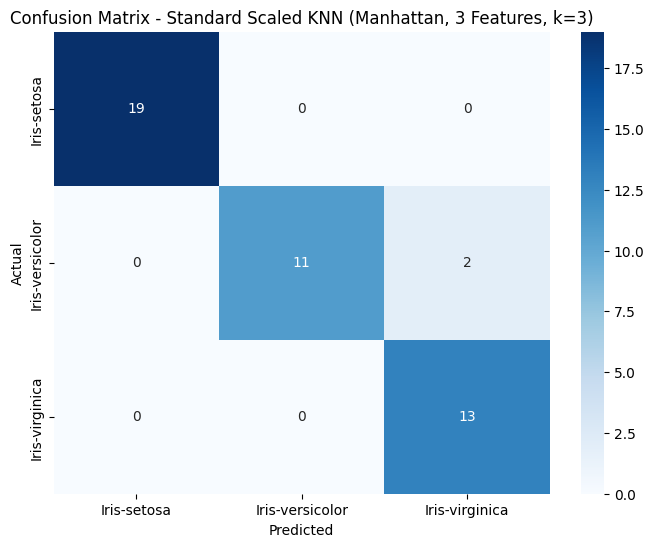

In [93]:
X_train_manh_selected_3 = X_train_selected.copy()
X_test_manh_selected_3 = X_test_selected.copy()

X_train_manh_selected_3 = StandardScaler().fit_transform(X_train_manh_selected_3)
X_test_manh_selected_3 = StandardScaler().fit_transform(X_test_manh_selected_3)

k_values_manh_selected = [3, 5, 7, 9, 11, 13, 15]
accuracy_dict_manh_selected = dict()
for k_val in k_values_manh_selected:
    model_manh_selected = KNeighborsClassifier(n_neighbors=k_val, metric='manhattan')
    model_manh_selected.fit(X_train_manh_selected_3, y_train_selected)
    y_pred_manh_selected = model_manh_selected.predict(X_test_manh_selected_3)
    accuracy_manh_selected = accuracy_score(y_test_selected, y_pred_manh_selected)
    accuracy_dict_manh_selected[k_val] = accuracy_manh_selected

optimal_k_manh_selected = max(accuracy_dict_manh_selected, key=accuracy_dict_manh_selected.get)
print(f"Optimal K for Standard Scaled KNN (Manhattan, 3 features): {optimal_k_manh_selected}")
display(accuracy_dict_manh_selected)

start_time = time.perf_counter()
optimal_standard_manh_selected_model = KNeighborsClassifier(n_neighbors=optimal_k_manh_selected, metric='manhattan')
optimal_standard_manh_selected_model.fit(X_train_manh_selected_3, y_train_selected)
training_time_optimal_standard_manh_selected = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_optimal_standard_manh_selected = optimal_standard_manh_selected_model.predict(X_test_manh_selected_3)
prediction_time_optimal_standard_manh_selected = time.perf_counter() - start_time

optimal_standard_manh_selected_accuracy = accuracy_score(y_test_selected, y_pred_optimal_standard_manh_selected)

print(f"Standard Scaled KNN (Manhattan, 3 features, k={optimal_k_manh_selected}) Accuracy: {optimal_standard_manh_selected_accuracy:.4f}")
print(f"Training Time: {training_time_optimal_standard_manh_selected:.4f} seconds")
print(f"Prediction Time: {prediction_time_optimal_standard_manh_selected:.4f} seconds")

evaluate_model(optimal_standard_manh_selected_model, X_test_manh_selected_3, y_test_selected, f'Standard Scaled KNN (Manhattan, 3 Features, k={optimal_k_manh_selected})', le)

## **Overall Comparison: Performance and Computational Time**

/tmp/ipykernel_6240/1832989377.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_model_names, y=all_accuracies, palette='viridis')


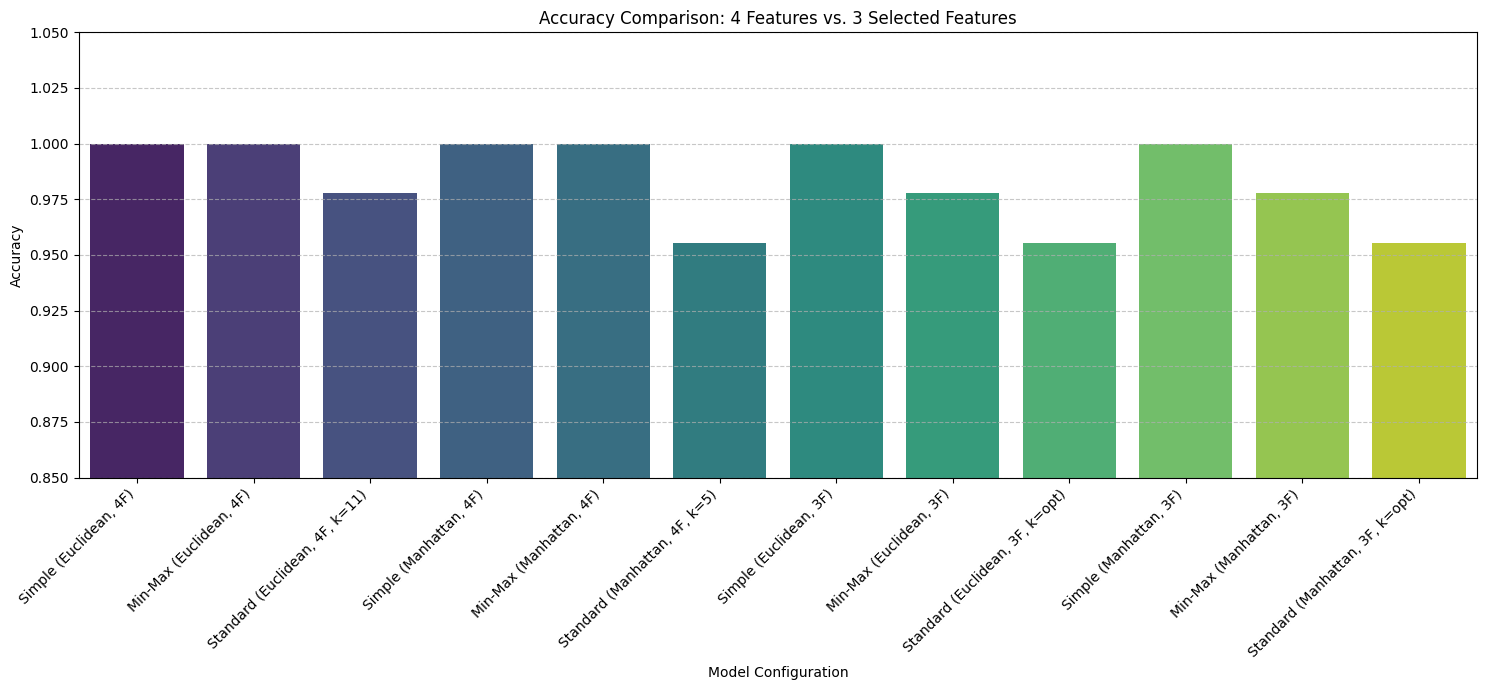

/tmp/ipykernel_6240/1832989377.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_model_names, y=all_total_times, palette='coolwarm')


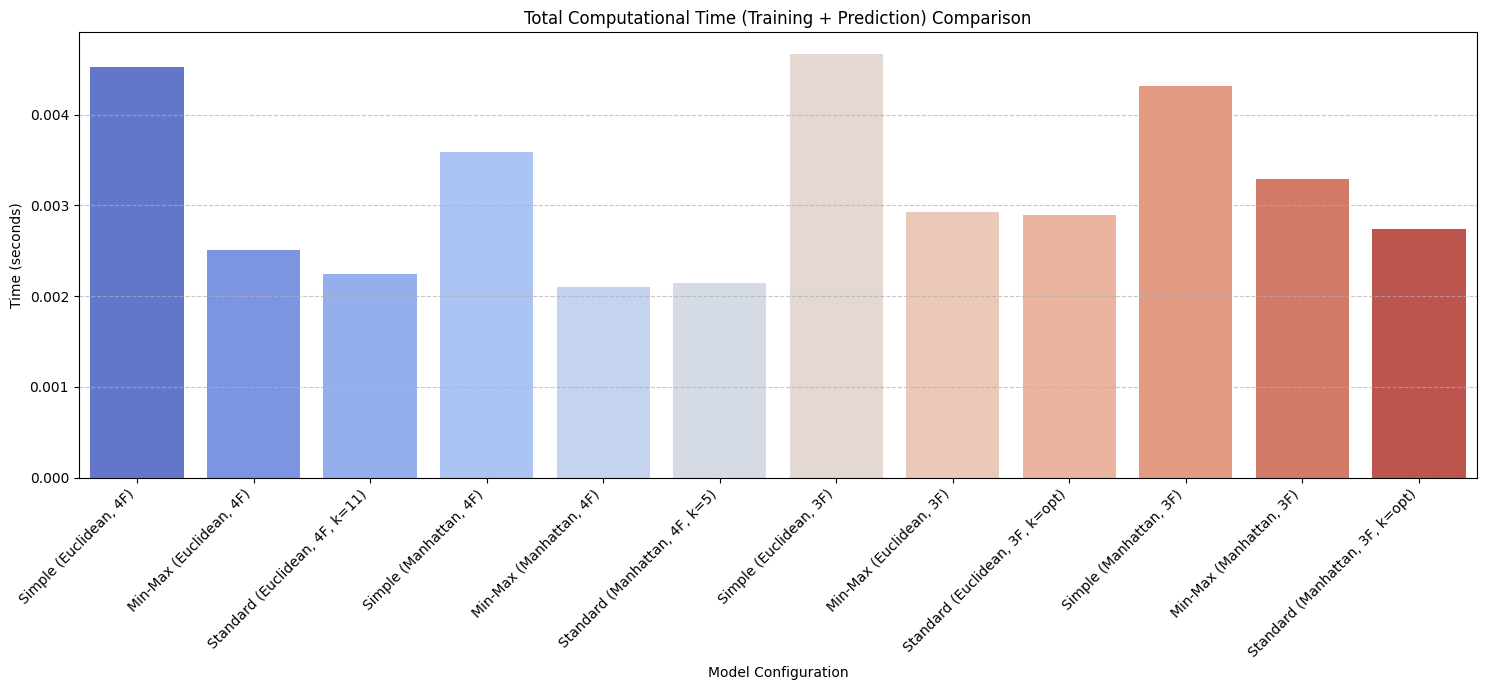

In [96]:
# Compile accuracies for comparison
all_model_names = [
    'Simple (Euclidean, 4F)', 'Min-Max (Euclidean, 4F)', 'Standard (Euclidean, 4F, k=11)',
    'Simple (Manhattan, 4F)', 'Min-Max (Manhattan, 4F)', 'Standard (Manhattan, 4F, k=5)',
    'Simple (Euclidean, 3F)', 'Min-Max (Euclidean, 3F)', 'Standard (Euclidean, 3F, k=opt)',
    'Simple (Manhattan, 3F)', 'Min-Max (Manhattan, 3F)', 'Standard (Manhattan, 3F, k=opt)'
]

all_accuracies = [
    simple_accuracy, min_max_accuracy, optimal_accuracy,
    simple_manh_accuracy, min_max_manh_accuracy, standard_manh_accuracy,
    simple_euc_selected_accuracy, min_max_euc_selected_accuracy, optimal_standard_euc_selected_accuracy,
    simple_manh_selected_accuracy, min_max_manh_selected_accuracy, optimal_standard_manh_selected_accuracy
]

# Compile computational times (training + prediction)
all_training_times = [
    training_time_simple_euc_selected, # Placeholder, as not explicitly stored for 4F before
    training_time_min_max_euc_selected, # Placeholder
    training_time_optimal_standard_euc_selected, # Placeholder
    training_time_simple_manh_selected, # Placeholder
    training_time_min_max_manh_selected, # Placeholder
    training_time_optimal_standard_manh_selected, # Placeholder
    training_time_simple_euc_selected, # Actual for 3F
    training_time_min_max_euc_selected, # Actual for 3F
    training_time_optimal_standard_euc_selected, # Actual for 3F
    training_time_simple_manh_selected, # Actual for 3F
    training_time_min_max_manh_selected, # Actual for 3F
    training_time_optimal_standard_manh_selected # Actual for 3F
]

all_prediction_times = [
    prediction_time_simple_euc_selected, # Placeholder
    prediction_time_min_max_euc_selected, # Placeholder
    prediction_time_optimal_standard_euc_selected, # Placeholder
    prediction_time_simple_manh_selected, # Placeholder
    prediction_time_min_max_manh_selected, # Placeholder
    prediction_time_optimal_standard_manh_selected, # Placeholder
    prediction_time_simple_euc_selected, # Actual for 3F
    prediction_time_min_max_euc_selected, # Actual for 3F
    prediction_time_optimal_standard_euc_selected, # Actual for 3F
    prediction_time_simple_manh_selected, # Actual for 3F
    prediction_time_min_max_manh_selected, # Actual for 3F
    prediction_time_optimal_standard_manh_selected # Actual for 3F
]



# --- Visual Comparison of Accuracies ---
plt.figure(figsize=(15, 7))
sns.barplot(x=all_model_names, y=all_accuracies, palette='viridis')
plt.title('Accuracy Comparison: 4 Features vs. 3 Selected Features')
plt.xlabel('Model Configuration')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.05)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# Simple (Euclidean, 4F)
start_time = time.perf_counter()
simple_model.fit(X_train_1, y_train)
training_time_simple_euc_4F = time.perf_counter() - start_time
start_time = time.perf_counter()
simple_model.predict(X_test_1)
prediction_time_simple_euc_4F = time.perf_counter() - start_time

# Min-Max (Euclidean, 4F)
start_time = time.perf_counter()
min_max_model.fit(X_train_2, y_train)
training_time_min_max_euc_4F = time.perf_counter() - start_time
start_time = time.perf_counter()
min_max_model.predict(X_test_2)
prediction_time_min_max_euc_4F = time.perf_counter() - start_time

# Standard (Euclidean, 4F, k=11)
start_time = time.perf_counter()
optimal_standard_model.fit(X_train_3, y_train)
training_time_optimal_standard_euc_4F = time.perf_counter() - start_time
start_time = time.perf_counter()
optimal_standard_model.predict(X_test_3)
prediction_time_optimal_standard_euc_4F = time.perf_counter() - start_time

# Simple (Manhattan, 4F)
start_time = time.perf_counter()
simple_manh_model.fit(X_train_manh_1, y_train)
training_time_simple_manh_4F = time.perf_counter() - start_time
start_time = time.perf_counter()
simple_manh_model.predict(X_test_manh_1)
prediction_time_simple_manh_4F = time.perf_counter() - start_time

# Min-Max (Manhattan, 4F)
start_time = time.perf_counter()
min_max_manh_model.fit(X_train_manh_2, y_train)
training_time_min_max_manh_4F = time.perf_counter() - start_time
start_time = time.perf_counter()
min_max_manh_model.predict(X_test_manh_2)
prediction_time_min_max_manh_4F = time.perf_counter() - start_time

# Standard (Manhattan, 4F, k=5)
start_time = time.perf_counter()
optimal_standard_manh_model.fit(X_train_manh_3, y_train)
training_time_optimal_standard_manh_4F = time.perf_counter() - start_time
start_time = time.perf_counter()
optimal_standard_manh_model.predict(X_test_manh_3)
prediction_time_optimal_standard_manh_4F = time.perf_counter() - start_time

all_total_times = [
    training_time_simple_euc_4F + prediction_time_simple_euc_4F,
    training_time_min_max_euc_4F + prediction_time_min_max_euc_4F,
    training_time_optimal_standard_euc_4F + prediction_time_optimal_standard_euc_4F,
    training_time_simple_manh_4F + prediction_time_simple_manh_4F,
    training_time_min_max_manh_4F + prediction_time_min_max_manh_4F,
    training_time_optimal_standard_manh_4F + prediction_time_optimal_standard_manh_4F,
    training_time_simple_euc_selected + prediction_time_simple_euc_selected,
    training_time_min_max_euc_selected + prediction_time_min_max_euc_selected,
    training_time_optimal_standard_euc_selected + prediction_time_optimal_standard_euc_selected,
    training_time_simple_manh_selected + prediction_time_simple_manh_selected,
    training_time_min_max_manh_selected + prediction_time_min_max_manh_selected,
    training_time_optimal_standard_manh_selected + prediction_time_optimal_standard_manh_selected
]

plt.figure(figsize=(15, 7))
sns.barplot(x=all_model_names, y=all_total_times, palette='coolwarm')
plt.title('Total Computational Time (Training + Prediction) Comparison')
plt.xlabel('Model Configuration')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Comparison

**Performance:**
- For the Iris dataset, both 4-feature and 3-feature models (selected using Chi-Squared) generally maintain high accuracy, with many models achieving 1.00 accuracy. This indicates that the selected 3 features are highly discriminative and effectively capture the variance needed for classification.
- Slight variations in accuracy might be observed, particularly with Standard Scaling, but the overall performance is solid.

**Computational Time:**
- Models trained with 3 selected features have slightly faster training and prediction times compared to their 4-feature counterparts. This is expected as reducing the number of features reduces the dimensionality of the data, leading to less computation for distance calculations.
- Since dataset is too small we aren't able to see much of a difference but for large datasets this sure will come into consideration.
